In [1]:
import sys
sys.path.append('..')
import os
os.chdir('..')

In [10]:
import json
# import os
from pathlib import Path
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import datasets
from transformers import AutoConfig, AutoTokenizer
from modeling_rmt.huggingface import RMTForReasoning, RMTConfig
import pickle
from tqdm import tqdm

# ===== Configuration matching the shell script =====
# Model architecture
L = 4
H = 4
D = 128
BASE_MODEL = "llama"
N_MEM_TOKENS = 1

# Dataset parameters
K = 2
V = 2
PAIRS_PER_SEGMENT = 8
N_SEGMENTS = 1
N_PAIRS = N_SEGMENTS * PAIRS_PER_SEGMENT

# Learning rate (for run name)
LR = 3e-04
N = 1  # run number
TBS = 64

# Paths
TOKENIZER_PATH = "./tokenizers/kv_alphabet_62/"
DATA_PATH = f"N{N_PAIRS}-K{K}V{V}-V62_1M"
# RUN_NAME = f"original_rmt_{BASE_MODEL}_L{L}H{H}D{D}_mem{N_MEM_TOKENS}_lr{LR}-{N_SEGMENTS}x{PAIRS_PER_SEGMENT}_bs_{TBS}_lr_{LR}-gen"
# EXP_PATH = f"./runs/{DATA_PATH}/{RUN_NAME}/run_{N}"

In [11]:
EXP_PATH = "/workspace-SR006.nfs2/bulatov/rmt/test-time/rmt_test_time_gd/runs/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem1_lr3e-04-1x8_bs_64_lr_3e-04-gen/run_1/checkpoint-158000/model.safetensors"
print(f"Loading checkpoint from: {EXP_PATH}")

# ===== Load tokenizer =====
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)
print(f"Tokenizer loaded with vocab size: {tokenizer.vocab_size}")

Loading checkpoint from: /workspace-SR006.nfs2/bulatov/rmt/test-time/rmt_test_time_gd/runs/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem1_lr3e-04-1x8_bs_64_lr_3e-04-gen/run_1/checkpoint-158000/model.safetensors
Tokenizer loaded with vocab size: 70


In [12]:

# ===== Create model config =====
if BASE_MODEL == 'llama':
    config = AutoConfig.from_pretrained('NousResearch/Llama-3.2-1B')
    config.num_hidden_layers = L
    config.num_attention_heads = H
    config.num_key_value_heads = H
    config.hidden_size = D
    config.head_dim = config.hidden_size // config.num_attention_heads
    config.intermediate_size = config.hidden_size * 4
elif BASE_MODEL == 'gpt2':
    config = AutoConfig.from_pretrained('gpt2')
    config.n_layer = L
    config.n_head = H
    config.n_embd = D
elif BASE_MODEL == 'pythia':
    config = AutoConfig.from_pretrained('EleutherAI/pythia-160m')
    config.num_hidden_layers = L
    config.num_attention_heads = H
    config.hidden_size = D
    config.intermediate_size = config.hidden_size * 4

config.torch_dtype = "float32"
config.vocab_size = tokenizer.vocab_size
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

# ===== Create RMT model =====
rmt_config = RMTConfig()
rmt_config.base_model_config = config
rmt_config.num_mem_tokens = N_MEM_TOKENS
rmt_config.max_n_segments = 10
rmt_config.think_token_id = tokenizer.convert_tokens_to_ids('[THINK]')
rmt_config.answer_token_id = tokenizer.convert_tokens_to_ids('[ANSWER]')
rmt_config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
rmt_config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

model = RMTForReasoning(rmt_config)
print(f"Model created: {model.__class__.__name__}")

# ===== Load checkpoint =====
model_cpt_path = EXP_PATH
use_safetensors = False

# Determine checkpoint file
if os.path.isdir(model_cpt_path):
    dir_files = os.listdir(model_cpt_path)
    if "model_best" in dir_files:
        candidate = os.path.join(model_cpt_path, "model_best", "pytorch_model.bin")
        if os.path.exists(candidate):
            model_cpt_path = candidate
        else:
            candidate_st = os.path.join(model_cpt_path, "model_best", "model.safetensors")
            if os.path.exists(candidate_st):
                model_cpt_path = candidate_st
                use_safetensors = True
    else:
        checkpoints = [el for el in dir_files if el.startswith("checkpoint-")]
        if checkpoints:
            checkpoint_dir = os.path.join(model_cpt_path, sorted(checkpoints)[-1])
            candidate = os.path.join(checkpoint_dir, "pytorch_model.bin")
            if os.path.exists(candidate):
                model_cpt_path = candidate
            else:
                candidate_st = os.path.join(checkpoint_dir, "model.safetensors")
                if os.path.exists(candidate_st):
                    model_cpt_path = candidate_st
                    use_safetensors = True

Model created: RMTForReasoning


In [13]:
use_safetensors = True
# Load weights
if use_safetensors:
    from safetensors.torch import load_model
    load_model(model, model_cpt_path)
else:
    cpt = torch.load(model_cpt_path, map_location='cpu', weights_only=False)
    model.load_state_dict(cpt, strict=False)

print(f"✓ Loaded checkpoint from: {model_cpt_path}")

# Move model to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# ===== Load dataset =====
dataset_name = f"N{N_PAIRS}-K{K}V{V}-V62_1M"
data_path = f"/workspace-SR006.nfs2/bulatov/rmt/data/associative_retrieval/{dataset_name}"
dataset = datasets.load_from_disk(data_path)
print(f"✓ Loaded dataset from: {data_path}")
print(f"  Train samples: {len(dataset['train'])}, Valid samples: {len(dataset['valid'])}")

✓ Loaded checkpoint from: /workspace-SR006.nfs2/bulatov/rmt/test-time/rmt_test_time_gd/runs/N8-K2V2-V62_1M/original_rmt_llama_L4H4D128_mem1_lr3e-04-1x8_bs_64_lr_3e-04-gen/run_1/checkpoint-158000/model.safetensors
✓ Loaded dataset from: /workspace-SR006.nfs2/bulatov/rmt/data/associative_retrieval/N8-K2V2-V62_1M
  Train samples: 1000000, Valid samples: 5000


In [14]:

# ===== Helper functions =====
def split_context_into_segments(context, pairs_per_segment=None):
    if pairs_per_segment is None:
        return [context]
    clean_context = context[1:-2].strip()
    pairs = [f"!{p}!" for p in clean_context.split("!!")]
    segments = [pairs[i:i + pairs_per_segment] for i in range(0, len(pairs), pairs_per_segment)]
    segments = [''.join(s) for s in segments]
    return segments

def prepare_sample(sample, pairs_per_segment=None):
    """Prepare a single sample for model inference"""
    def encode(text):
        return tokenizer.encode(text, add_special_tokens=False)
    
    context = sample['context']
    query = sample['query']
    target = sample['target']
    
    query_ids = encode(query)
    target_ids = encode(target)
    qt_ids = query_ids + target_ids
    context_pairs = split_context_into_segments(context, pairs_per_segment=pairs_per_segment)
    
    segments = []
    for context_pair in context_pairs:
        context_ids = encode(context_pair)
        seg = {
            'input_ids': torch.tensor(context_ids, dtype=torch.long),
            'attention_mask': torch.ones(len(context_ids), dtype=torch.long),
        }
        segments.append(seg)
    
    # Query+target segment
    qt_input_ids = torch.tensor(qt_ids, dtype=torch.long)
    qt_attention_mask = torch.ones(len(qt_ids), dtype=torch.long)
    segments.append({
        'input_ids': qt_input_ids,
        'attention_mask': qt_attention_mask,
    })
    
    return segments, query_ids, target_ids

# ===== Evaluation function =====
@torch.no_grad()
def evaluate_and_save_predictions(model, dataset_split, pairs_per_segment=PAIRS_PER_SEGMENT, 
                                   max_samples=None, output_file='predictions.pkl'):
    """
    Evaluate model and save predictions for interpretation
    """
    model.eval()
    
    results = []
    dataset_to_eval = dataset_split if max_samples is None else dataset_split.select(range(min(max_samples, len(dataset_split))))
    
    for idx, sample in enumerate(tqdm(dataset_to_eval)):
        segments, query_ids, target_ids = prepare_sample(sample, pairs_per_segment=pairs_per_segment)
        
        # Prepare batch segments (batch size = 1)
        batch_segments = []
        for seg in segments:
            batch_segments.append({
                'input_ids': seg['input_ids'].unsqueeze(0).to(device),
                'attention_mask': seg['attention_mask'].unsqueeze(0).to(device),
            })
        
        # Get model predictions
        outputs = model(segments=batch_segments)
        logits = outputs.logits  # shape: (batch=1, total_seq_len, vocab_size)
        
        # Get predictions for the last segment (query+target)
        # The target starts at position len(query_ids)
        last_segment_len = len(query_ids) + len(target_ids)
        last_segment_logits = logits[0, -last_segment_len:, :]
        
        # Get predicted tokens for target positions
        target_start_pos = len(query_ids) - 1  # -1 because we predict next token
        predicted_ids = torch.argmax(last_segment_logits[target_start_pos:], dim=-1).cpu().numpy()
        
        # Decode
        predicted_text = tokenizer.decode(predicted_ids, skip_special_tokens=True).replace(' ', '')
        target_text = tokenizer.decode(target_ids, skip_special_tokens=True).replace(' ', '')
        query_text = tokenizer.decode(query_ids, skip_special_tokens=True).replace(' ', '')
        
        # Check correctness
        correct = predicted_text == target_text
        
        result = {
            'idx': idx,
            'context': sample['context'],
            'query': query_text,
            'target': target_text,
            'predicted': predicted_text,
            'correct': correct,
            'target_ids': target_ids,
            'predicted_ids': predicted_ids.tolist(),
        }
        results.append(result)
    
    # Compute accuracy
    accuracy = np.mean([r['correct'] for r in results])
    print(f"\n{'='*50}")
    print(f"Evaluation complete!")
    print(f"Total samples: {len(results)}")
    print(f"Accuracy: {accuracy:.4f} ({sum([r['correct'] for r in results])}/{len(results)})")
    print(f"{'='*50}\n")
    
    # Save predictions
    output_path = os.path.join(EXP_PATH, output_file)
    with open(output_path, 'wb') as f:
        pickle.dump({
            'results': results,
            'accuracy': accuracy,
            'config': {
                'exp_path': EXP_PATH,
                'n_pairs': N_PAIRS,
                'k': K,
                'v': V,
                'pairs_per_segment': pairs_per_segment,
            }
        }, f)
    print(f"✓ Saved predictions to: {output_path}")
    
    # Show a few examples
    print("\nSample predictions:")
    for i, r in enumerate(results[:5]):
        print(f"\n--- Sample {i+1} ---")
        print(f"Query:     {r['query']}")
        print(f"Target:    {r['target']}")
        print(f"Predicted: {r['predicted']}")
        print(f"Correct:   {'✓' if r['correct'] else '✗'}")
    
    return results, accuracy

In [ ]:

# ===== Run evaluation =====
# Evaluate on validation set (you can change to dataset['train'] if needed)
results, accuracy = evaluate_and_save_predictions(
    model, 
    dataset['valid'], 
    pairs_per_segment=PAIRS_PER_SEGMENT,
    max_samples=1000,  # Set to None to evaluate all samples
    output_file='predictions_valid.pkl'
)

In [15]:
import matplotlib.pyplot as plt
import matplotlib

# ===== Pick a sample =====
sample_idx = 0
sample = dataset['valid'][sample_idx]
segments, query_ids, target_ids = prepare_sample(sample, pairs_per_segment=PAIRS_PER_SEGMENT)

print(f"Context: {sample['context']}")
print(f"Query:   {sample['query']}")
print(f"Target:  {sample['target']}")
print(f"Number of segments: {len(segments)}")

Context: !y2:Km!!n0:gT!!MN:gl!!iD:MC!!RD:Sb!!i4:vF!!JP:Ag!!uB:aM!|
Query:   ?!n0:
Target:  gT!|
Number of segments: 2


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


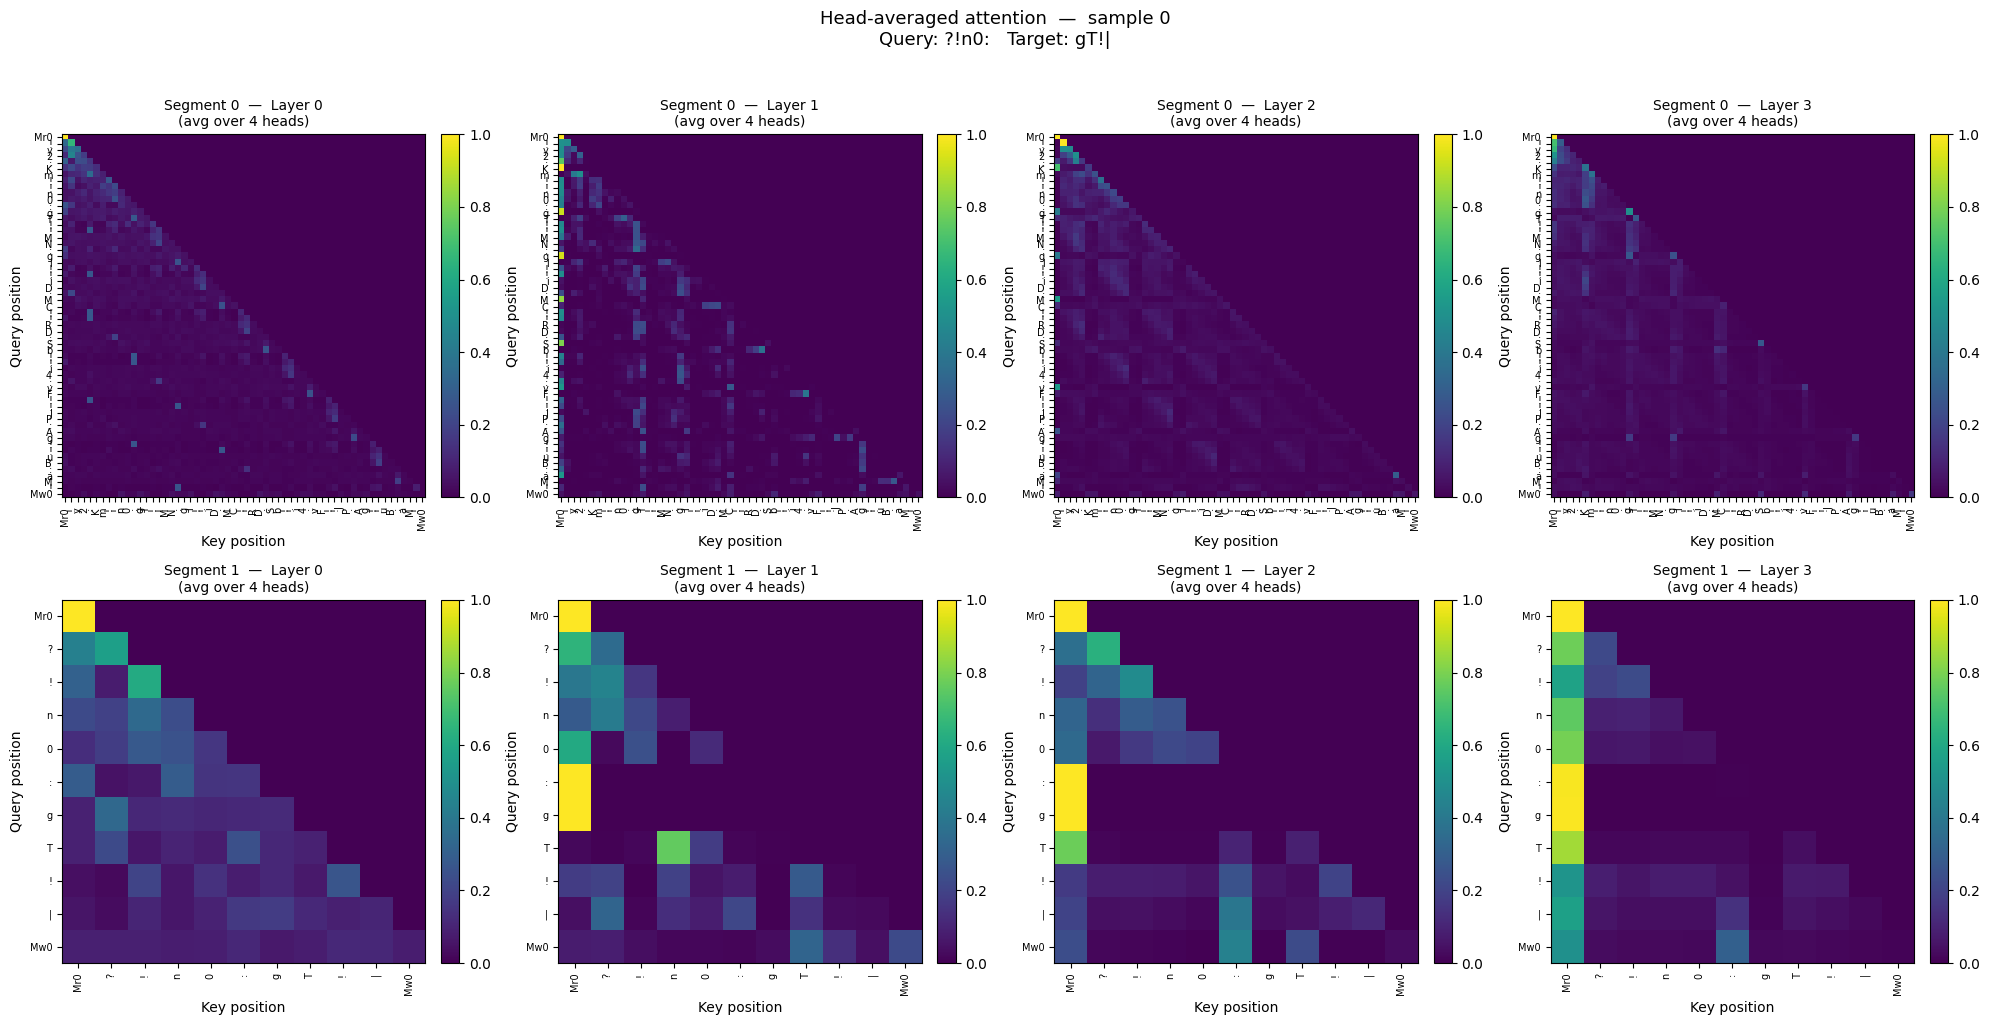

In [16]:

# ===== Run model segment-by-segment with output_attentions=True =====
memory_cell = model.rmt.memory_cell
num_mem = memory_cell.num_mem_tokens

all_attentions = []    # one entry per segment; each is a tuple of (batch, heads, seq, seq) per layer
all_token_labels = []  # one list of string labels per segment

memory_state = None
with torch.no_grad():
    for seg_idx, seg in enumerate(segments):
        input_ids = seg['input_ids'].unsqueeze(0).to(device)
        attention_mask = seg['attention_mask'].unsqueeze(0).to(device)

        cell_out, memory_state = memory_cell(
            input_ids=input_ids,
            attention_mask=attention_mask,
            memory_state=memory_state,
            output_attentions=True,
        )

        all_attentions.append(cell_out.attentions)   # tuple of n_layers tensors

        # Build human-readable tick labels:
        #   [M_r0, ..., M_r{n-1}] + [decoded input tokens] + [M_w0, ..., M_w{n-1}]
        input_token_ids = seg['input_ids'].tolist()
        tok_strs = [tokenizer.decode([t]) for t in input_token_ids]
        labels = ([f"Mr{i}" for i in range(num_mem)]
                  + tok_strs
                  + [f"Mw{i}" for i in range(num_mem)])
        all_token_labels.append(labels)

# ===== Plot: head-averaged attention, one column per layer, one row per segment =====
n_layers = len(all_attentions[0])
n_heads  = all_attentions[0][0].shape[1]
n_segs   = min(2, len(segments))          # first two segments

fig, axes = plt.subplots(
    n_segs, n_layers,
    figsize=(5 * n_layers, 5 * n_segs),
    squeeze=False,
)

for seg_idx in range(n_segs):
    seg_attn = all_attentions[seg_idx]
    labels   = all_token_labels[seg_idx]

    for layer_idx in range(n_layers):
        attn = seg_attn[layer_idx][0]                 # (heads, seq, seq)
        attn_avg = attn.mean(dim=0).cpu().float().numpy()

        ax = axes[seg_idx][layer_idx]
        im = ax.imshow(attn_avg, cmap='viridis', aspect='auto')
        ax.set_title(f"Segment {seg_idx}  —  Layer {layer_idx}\n(avg over {n_heads} heads)", fontsize=10)
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_xlabel("Key position")
        ax.set_ylabel("Query position")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"Head-averaged attention  —  sample {sample_idx}\n"
    f"Query: {sample['query']}   Target: {sample['target']}",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

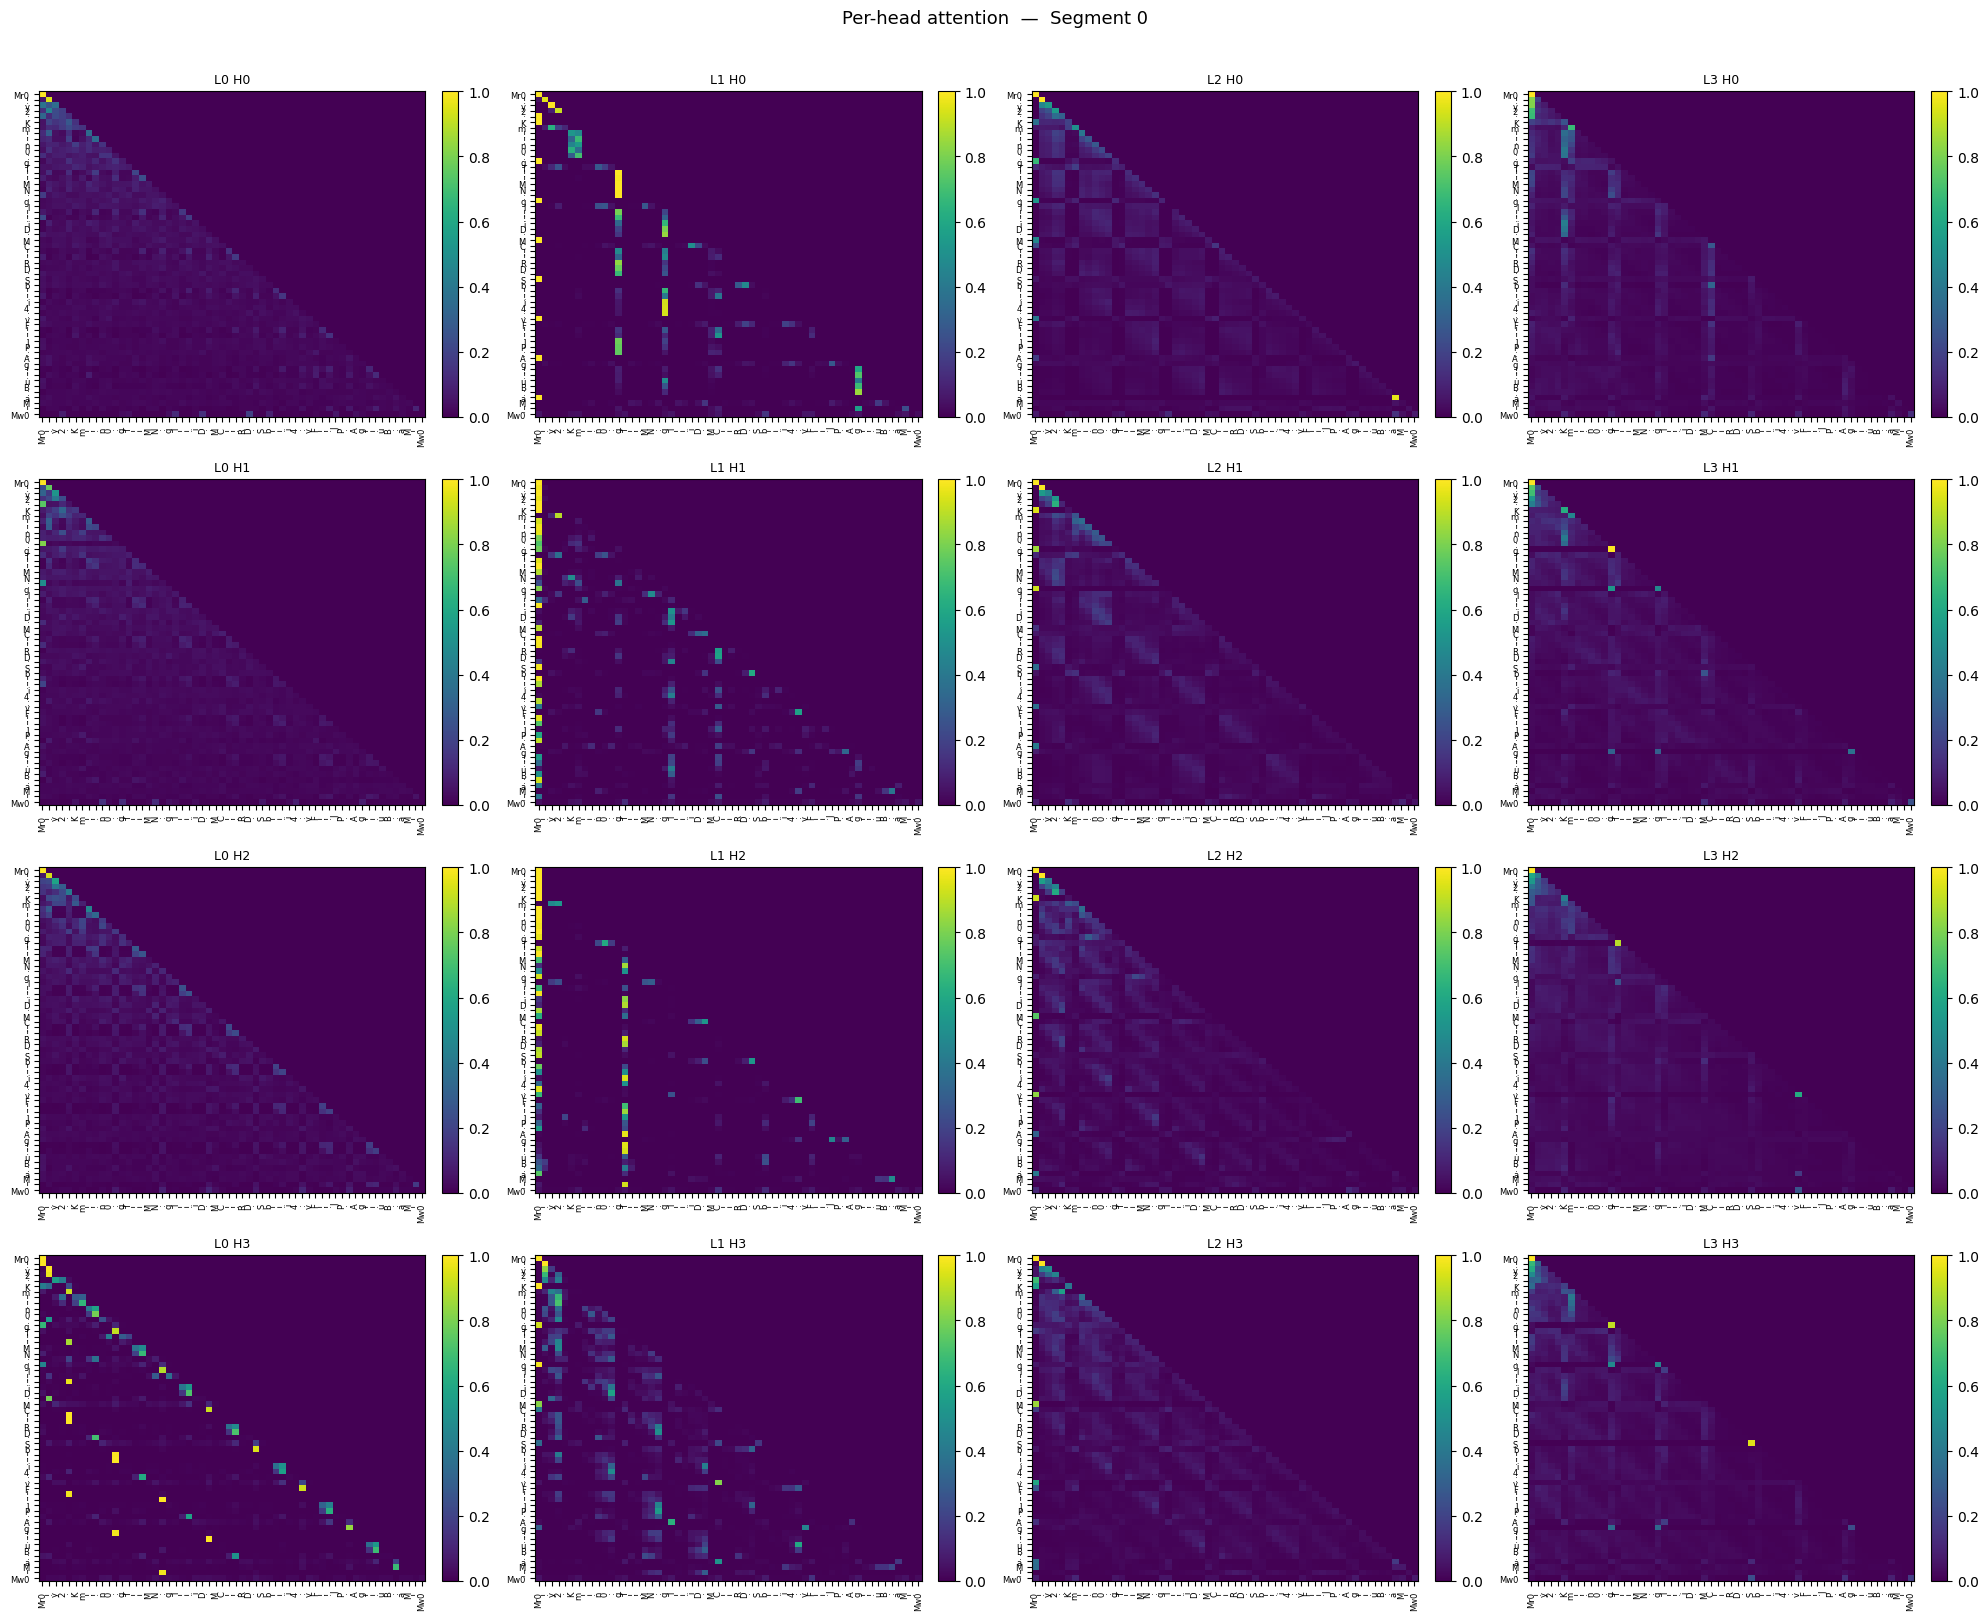

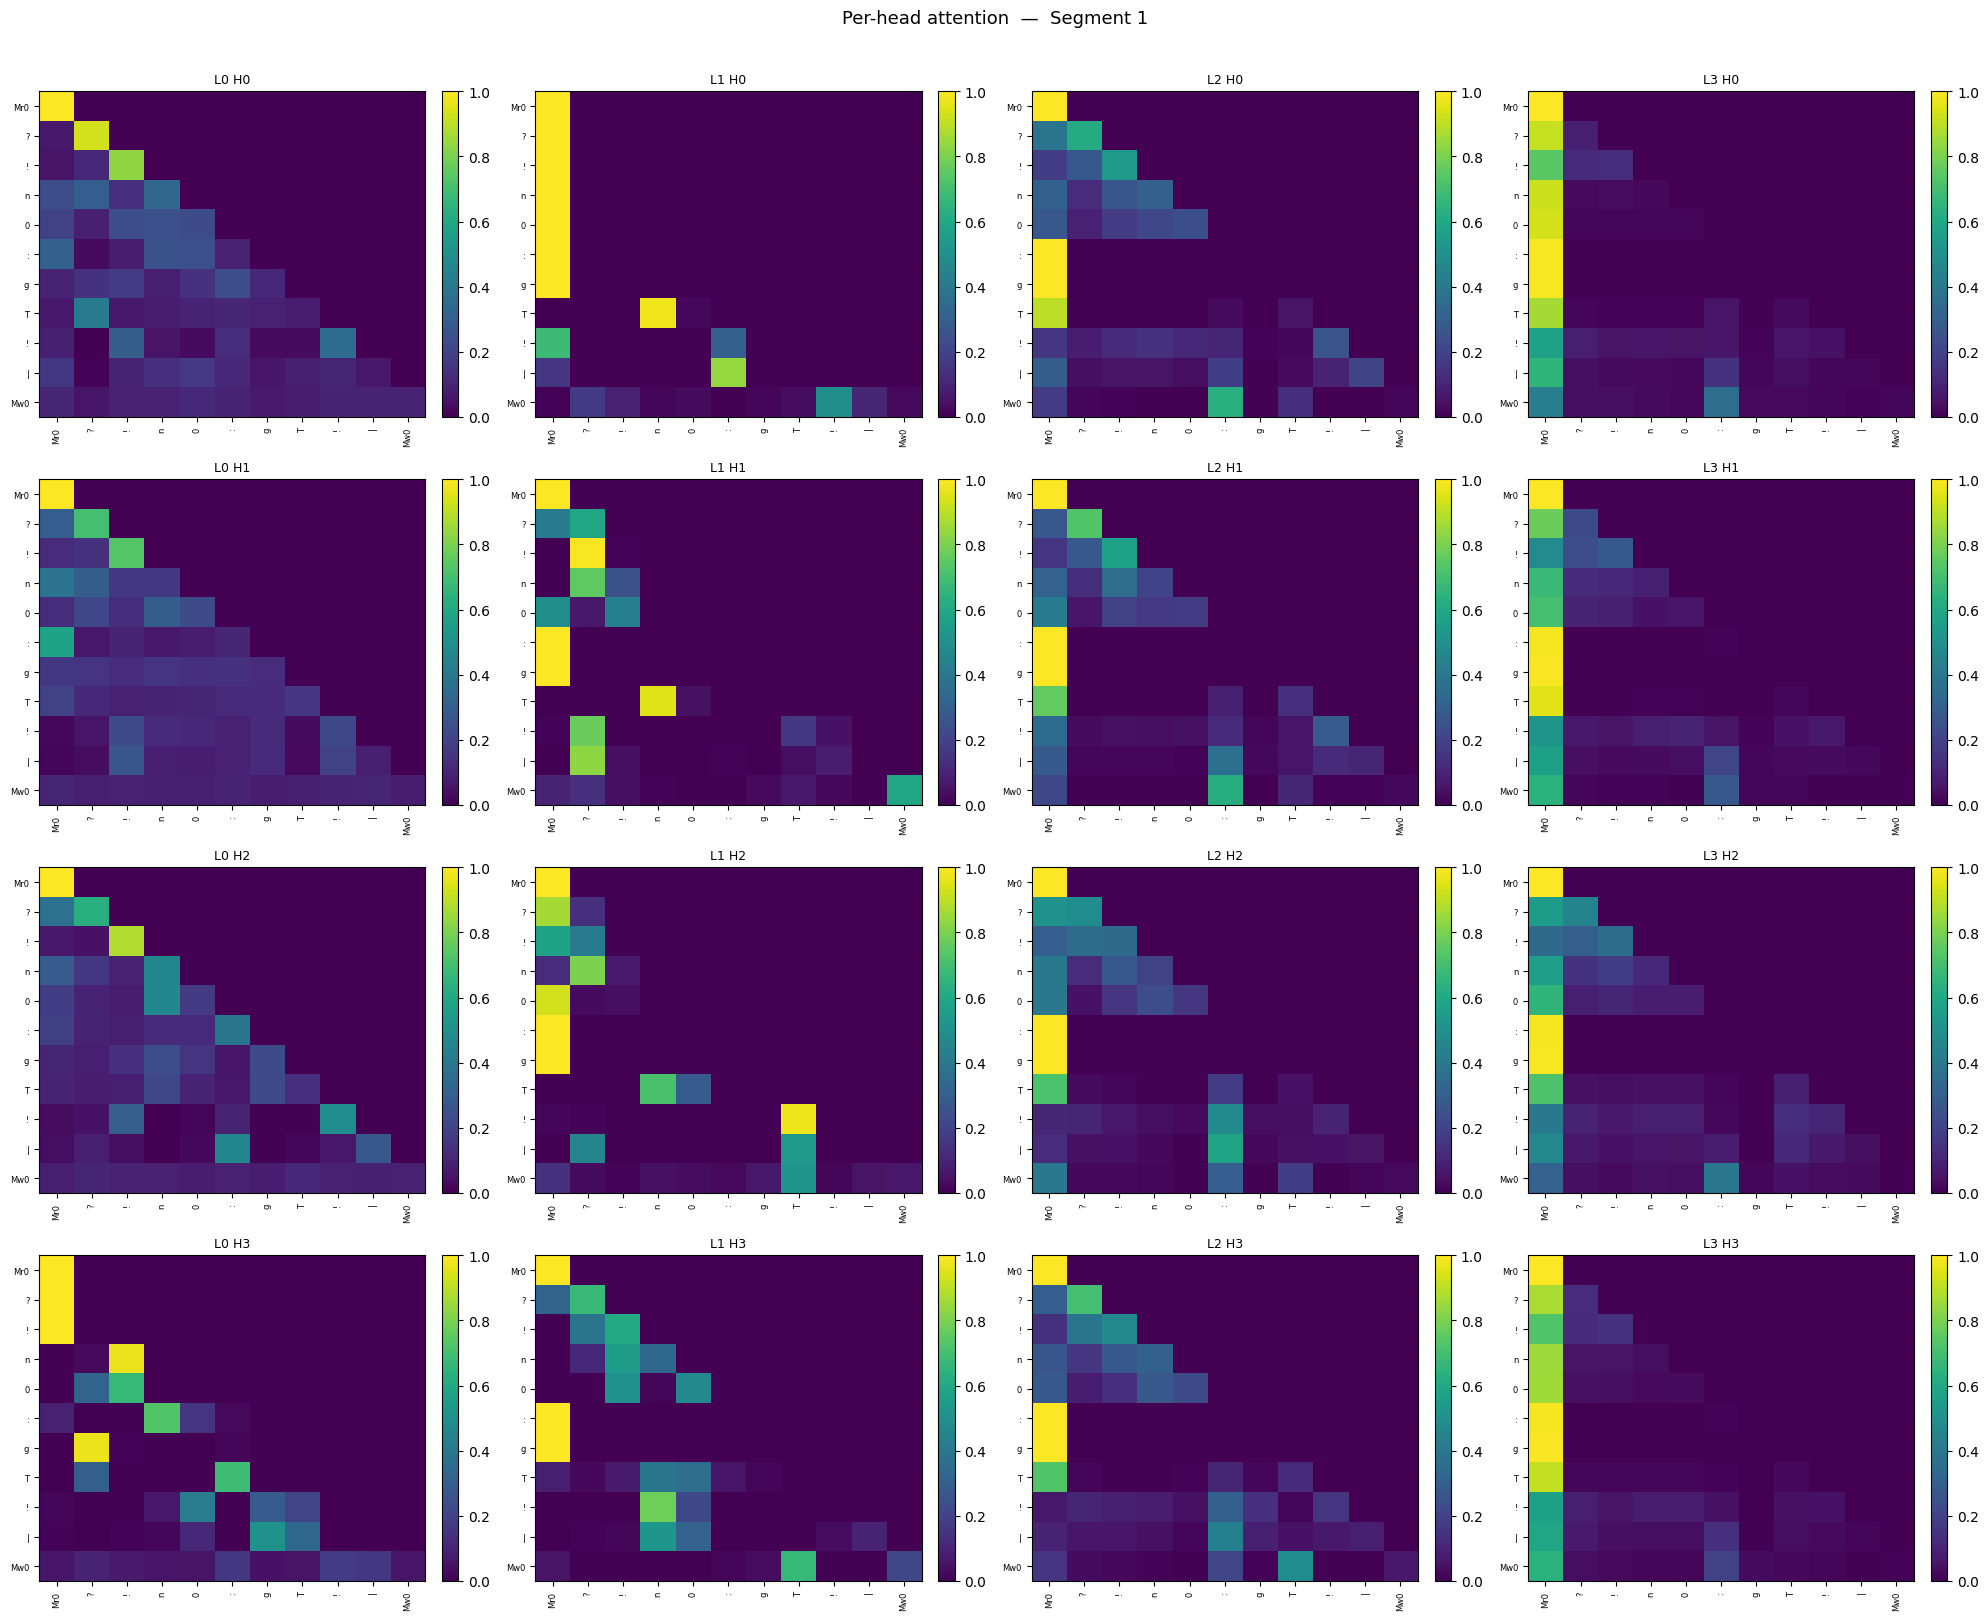

In [17]:

# ===== Plot: per-head attention for each segment (separate figure) =====
for seg_idx in range(n_segs):
    seg_attn = all_attentions[seg_idx]
    labels   = all_token_labels[seg_idx]

    fig_h, axes_h = plt.subplots(
        n_heads, n_layers,
        figsize=(5 * n_layers, 4 * n_heads),
        squeeze=False,
    )

    for layer_idx in range(n_layers):
        attn = seg_attn[layer_idx][0].cpu().float().numpy()   # (heads, seq, seq)
        for head_idx in range(n_heads):
            ax = axes_h[head_idx][layer_idx]
            im = ax.imshow(attn[head_idx], cmap='viridis', aspect='auto')
            ax.set_title(f"L{layer_idx} H{head_idx}", fontsize=9)
            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=90, fontsize=6)
            ax.set_yticklabels(labels, fontsize=6)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig_h.suptitle(f"Per-head attention  —  Segment {seg_idx}", fontsize=13, y=1.01)
    fig_h.tight_layout()
    plt.show()